# Building a Simple Web Agent

In [1]:
import asyncio
import json
import os
import nest_asyncio
import pprint
import base64
from io import BytesIO
import pandas as pd
from playwright.async_api import async_playwright
from openai import OpenAI
from PIL import Image
from tabulate import tabulate
from IPython.display import display, HTML, Markdown
from pydantic import BaseModel
from helper import get_openai_api_key, visualizeCourses

In [2]:
client = OpenAI(api_key=get_openai_api_key())
nest_asyncio.apply()

## WebScraper Agent

In [3]:
class WebScraperAgent:
    def __init__(self):
        self.playwright = None
        self.browser = None
        self.page = None

    async def init_browser(self):
      self.playwright = await async_playwright().start()
      self.browser = await self.playwright.chromium.launch(
          headless=True,
          args=[
              "--disable-dev-shm-usage",
              "--no-sandbox",
              "--disable-setuid-sandbox",
              "--disable-accelerated-2d-canvas",
              "--disable-gpu",
              "--no-zygote",
              "--disable-audio-output",
              "--disable-software-rasterizer",
              "--disable-webgl",
              "--disable-web-security",
              "--disable-features=LazyFrameLoading",
              "--disable-features=IsolateOrigins",
              "--disable-background-networking"
          ]
      )
      self.page = await self.browser.new_page()

    async def scrape_content(self, url):
        if not self.page or self.page.is_closed():
            await self.init_browser()
        await self.page.goto(url, wait_until="load")
        await self.page.wait_for_timeout(2000)  # Wait for dynamic content
        return await self.page.content()

    async def take_screenshot(self, path="screenshot.png"):
        await self.page.screenshot(path=path, full_page=True)
        return path
    async def screenshot_buffer(self):
        screenshot_bytes = await self.page.screenshot(type="png", full_page=False)
        return screenshot_bytes

    async def close(self):
        await self.browser.close()
        await self.playwright.stop()
        self.playwright = None
        self.browser = None
        self.page = None

In [4]:
scraper = WebScraperAgent()

##from playwright.async_api import async_playwright

class WebScraperAgent:
    def __init__(self):
        self.playwright = None
        self.browser = None
        self.page = None
        self.context = None

    async def init_browser(self):
        """Initialize browser with robust error handling"""
        try:
            self.playwright = await async_playwright().start()
            
            self.browser = await self.playwright.chromium.launch(
                headless=True,
                args=[
                    "--disable-dev-shm-usage",
                    "--no-sandbox",
                    "--disable-setuid-sandbox",
                    "--disable-accelerated-2d-canvas",
                    "--disable-gpu",
                    "--no-zygote",
                    "--disable-audio-output",
                    "--disable-software-rasterizer",
                    "--disable-webgl",
                    "--disable-web-security",
                    "--disable-features=LazyFrameLoading",
                    "--disable-features=IsolateOrigins",
                    "--disable-background-networking"
                ]
            )
            
            self.context = await self.browser.new_context(
                viewport={"width": 1920, "height": 1080}
            )
            self.page = await self.context.new_page()
            
            print("✅ Browser launched successfully")
            
        except Exception as e:
            print(f"❌ Failed to launch browser: {e}")
            await self.close()
            raise

    async def scrape_content(self, url: str):
        """Scrape HTML content from a URL"""
        if not self.page or self.page.is_closed():
            await self.init_browser()
        
        try:
            await self.page.goto(url, wait_until="networkidle", timeout=30000)
            await self.page.wait_for_timeout(2000)  # Wait for dynamic content
            return await self.page.content()
        except Exception as e:
            print(f"❌ Error scraping {url}: {e}")
            return None

    async def take_screenshot(self, path: str = "screenshot.png"):
        """Take full page screenshot"""
        try:
            await self.page.screenshot(path=path, full_page=True)
            print(f"✅ Screenshot saved to {path}")
            return path
        except Exception as e:
            print(f"❌ Screenshot failed: {e}")
            return None

    async def screenshot_buffer(self):
        """Return screenshot as bytes"""
        try:
            screenshot_bytes = await self.page.screenshot(type="png", full_page=False)
            return screenshot_bytes
        except Exception as e:
            print(f"❌ Screenshot buffer failed: {e}")
            return None

    async def close(self):
        """Safely close all resources"""
        try:
            if self.browser is not None:
                await self.browser.close()
        except Exception as e:
            print(f"Warning: Error closing browser: {e}")

        try:
            if self.playwright is not None:
                await self.playwright.stop()
        except Exception as e:
            print(f"Warning: Error stopping playwright: {e}")

        # Reset all references
        self.playwright = None
        self.browser = None
        self.context = None
        self.page = NoneStructured Data Format

In [11]:
class DeeplearningCourse(BaseModel):
    title: str
    description: str
    presenter: list[str]
    imageUrl: str
    courseURL: str

class DeeplearningCourseList(BaseModel):
    courses: list[DeeplearningCourse]

## LLM Client for Open AI

In [19]:
async def process_with_llm(html, instructions, truncate = False):
    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini-2024-07-18",
        messages=[{
            "role": "system",
            "content": f"""
            You are an expert web scraping agent. Your task is to:
            Extract relevant information from this HTML to JSON 
            following these instructions:
            {instructions}
            
            Extract the title, description, presenter, 
            the image URL and course URL for each of 
            all the courses for the deeplearning.ai website

            Return ONLY valid JSON, no markdown or extra text."""
        }, {
            "role": "user",
            "content": html[:300000]  # Truncate to stay under token limits
        }],
        temperature=0.1,
        response_format=DeeplearningCourseList,
        )
    return completion.choices[0].message.parsed

In [20]:
async def webscraper(target_url, instructions):
    result = None
    try:
        # Scrape content and capture screenshot
        print("Extracting HTML Content \n")
        html_content = await scraper.scrape_content(target_url)

        print("Taking Screenshot \n")
        screenshot = await scraper.screenshot_buffer()
        # Process content

        print("Processing..")
        result: DeeplearningCourseList = await process_with_llm(html_content, instructions, False)
        print("\nGenerated Structured Response")
    except Exception as e:
        print(f"❌ Error: {str(e)}")
    finally:
        await scraper.close()
    return result, screenshot

## Example 1

In [21]:
target_url = "https://www.deeplearning.ai/courses"  # Deeplearning AI courses
base_url="https://deeplearning.ai"

In [22]:
instructions = """
    Get all the courses
"""
result, screenshot = await webscraper(target_url, instructions)

Extracting HTML Content 

Taking Screenshot 

Processing..

Generated Structured Response


### Scraped Course Data:

title,description,presenter,imageUrl,courseURL
Fast LLM Inference with Cerebras,"This course, built in partnership with Cerebras and taught by Zhenwei Gao, Sebastian Duerr, and Sarah Chieng of Cerebras, shows you how to build LLM applications that respond in real time on Cerebras' Wafer-Scale Engine (WSE-3). It's a chip large enough to hold a model's weights on-chip, right next to the compute units. You'll run fast inference and see where that speed matters most: latency-sensitive use cases like live personalization and real-time multi-tool workflows.","Zhenwei Gao, Sebastian Duerr, Sarah Chieng",,Fast LLM Inference with Cerebras
Voice for AI Agents and Applications,"Add voice to your AI agents and applications using three integration patterns: embedded voice, voice layered on existing agents, and voice as a callable tool.",Vocal Bridge,,Voice for AI Agents and Applications
Fast & Efficient LLM Inference with vLLM,"Optimize, deploy, and benchmark an open-source LLM with vLLM.",Red Hat,,Fast & Efficient LLM Inference with vLLM
AI Agents for Image and Video Generation,"Build AI agents that generate images and videos, evaluate output automatically, and iterate until results meet your quality standards.",Google,,AI Agents for Image and Video Generation
Transformers in Practice,"Go beyond just using LLMs to actually understanding them. In this course taught by Sharon Zhou, you'll build the intuition to reason about model behavior, debug real problems, and make smarter decisions about deploying transformer-based models.",AMD,,Transformers in Practice
Building Interactive Agents with Generative UI,"Build fullstack agent apps that go beyond plain text, generating custom UIs like charts, forms, and whiteboards on demand.",CopilotKit,,Building Interactive Agents with Generative UI
AI Prompting for Everyone,"Become an AI power user in this new course taught by Andrew Ng. From finding information to building apps, you'll develop the prompting skills that get real, useful results from today's most powerful AI models.",DeepLearning.AI,,AI Prompting for Everyone
Building Multimodal Data Pipelines,"Learn to build AI-powered pipelines that turn images, audio, and video into LLM-ready text, and power multimodal applications on top.",Snowflake,,Building Multimodal Data Pipelines
Spec-Driven Development with Coding Agents,"Move beyond vibe coding: write clear specs that give your coding agent the context it needs to build intentional, maintainable software.",JetBrains,,Spec-Driven Development with Coding Agents
Efficient Inference with SGLang: Text and Image Generation,"Learn how LLM inference works under the hood and implement caching optimizations, including KV cache and RadixAttention, to make text and image generation faster and cheaper.","RadixArk, LMSys",,Efficient Inference with SGLang: Text and Image Generation


### Website Screenshot:


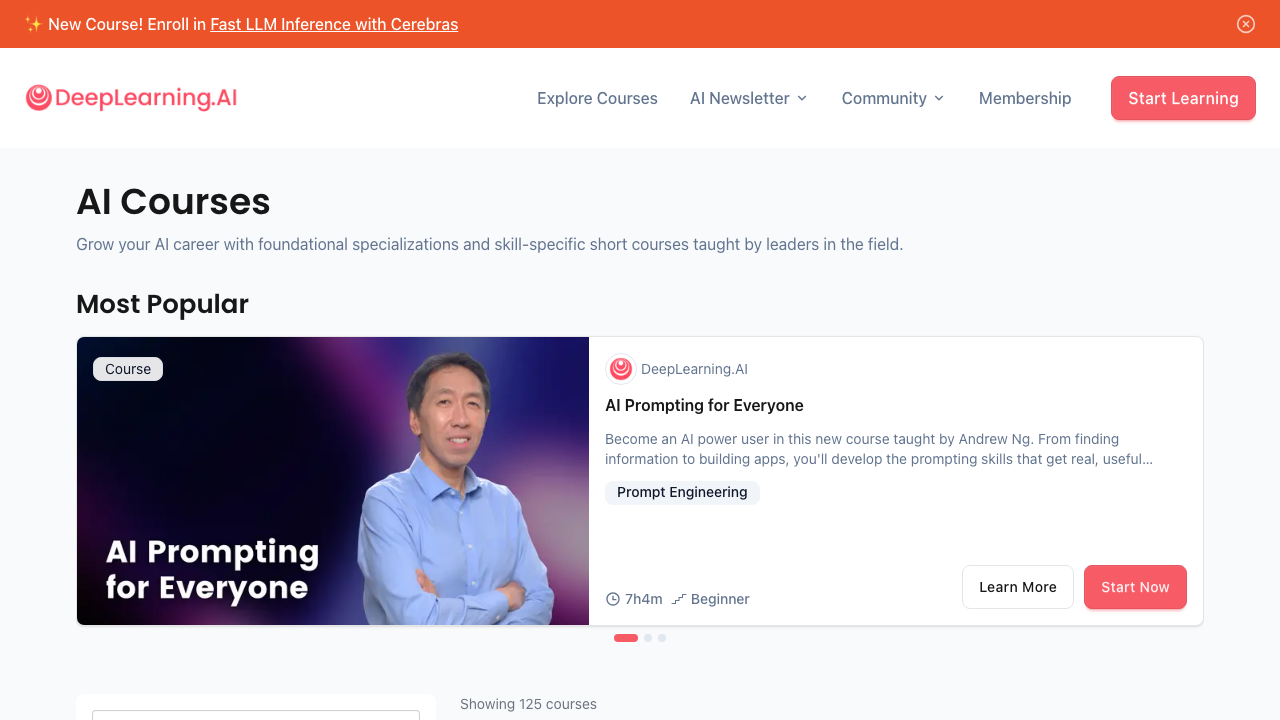

In [23]:
await visualizeCourses(result=result, 
                       screenshot=screenshot, 
                       target_url=target_url, 
                       instructions=instructions, 
                       base_url=base_url)

## Example with RAG courses

In [24]:
subject = "Retrieval Augmented Generation (RAG) "

instructions = f"""
Read the description of the courses and only 
provide the three courses that are about {subject}. 
Make sure that we don't have any other
cources in the output
"""
result, screenshot = await webscraper(target_url, instructions)

Extracting HTML Content 

Taking Screenshot 

Processing..

Generated Structured Response


### Scraped Course Data:

title,description,presenter,imageUrl,courseURL
Agent Memory: Building Memory-Aware Agents,"Build a complete agent memory system that lets an LLM store, retrieve, and refine knowledge across sessions—turning a stateless agent into one that learns and improves over time.",DeepLearning.AI,,Agent Memory: Building Memory-Aware Agents
Multi-vector Image Retrieval,"Build advanced retrieval systems that represent images with multiple vectors, enabling fine-grained matching between text queries and visual content for accurate multi-modal search.",Qdrant,,Multi-vector Image Retrieval
Efficient Inference with SGLang: Text and Image Generation,"Learn how LLM inference works under the hood and implement caching optimizations, including KV cache and RadixAttention, to make text and image generation faster and cheaper.","RadixArk, LMSys",,Efficient Inference with SGLang: Text and Image Generation


### Website Screenshot:


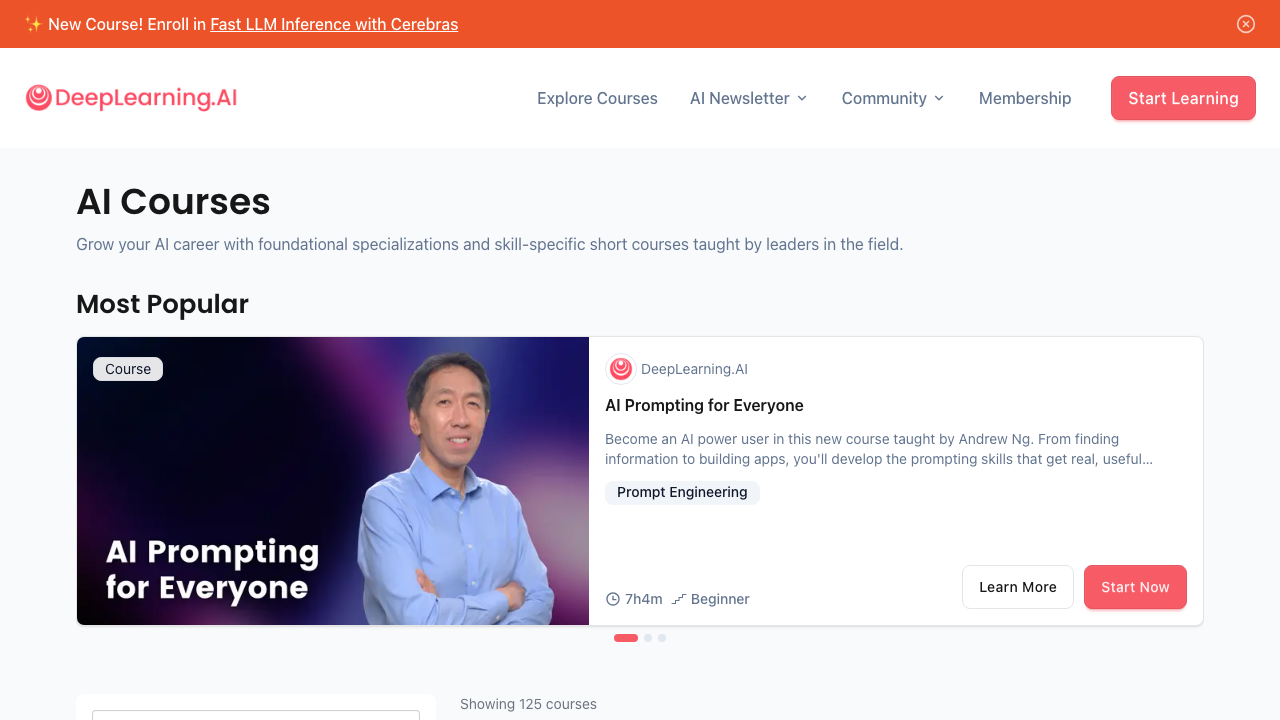

In [25]:
await visualizeCourses(result=result, 
                       screenshot=screenshot, 
                       target_url=target_url, 
                       instructions=instructions, 
                       base_url=base_url)

## Challenges in the web agents

In [26]:
subject = "Retrieval Augmented Generation (RAG) "
instructions = f"""
Can you get the summary of the top course on
{subject} provide the learnings from it
"""
result, screenshot = await webscraper(target_url, instructions)

Extracting HTML Content 

Taking Screenshot 

Processing..

Generated Structured Response


### Scraped Course Data:

title,description,presenter,imageUrl,courseURL
AI Prompting for Everyone,"Become an AI power user in this new course taught by Andrew Ng. From finding information to building apps, you'll develop the prompting skills that get real, useful results from today's most powerful AI models.",DeepLearning.AI,,AI Prompting for Everyone
Build with Andrew,"If you've never written code before, this course is for you. In less than 30 minutes, you'll learn to describe an idea in words and let AI transform it into an app for you.",DeepLearning.AI,,Build with Andrew
Agentic AI,"In this course taught by Andrew Ng, you'll build agentic AI systems that take action through iterative, multi-step workflows.",DeepLearning.AI,,Agentic AI
Fast LLM Inference with Cerebras,"This course, built in partnership with Cerebras and taught by Zhenwei Gao, Sebastian Duerr, and Sarah Chieng of Cerebras, shows you how to build LLM applications that respond in real time on Cerebras' Wafer-Scale Engine (WSE-3). It's a chip large enough to hold a model's weights on-chip, right next to the compute units. You'll run fast inference and see where that speed matters most: latency-sensitive use cases like live personalization and real-time multi-tool workflows.",Cerebras,,Fast LLM Inference with Cerebras
Voice for AI Agents and Applications,"Add voice to your AI agents and applications using three integration patterns: embedded voice, voice layered on existing agents, and voice as a callable tool.",Vocal Bridge,,Voice for AI Agents and Applications
Fast & Efficient LLM Inference with vLLM,"Optimize, deploy, and benchmark an open-source LLM with vLLM.",Red Hat,,Fast & Efficient LLM Inference with vLLM
AI Agents for Image and Video Generation,"Build AI agents that generate images and videos, evaluate output automatically, and iterate until results meet your quality standards.",Google,,AI Agents for Image and Video Generation
Transformers in Practice,"Go beyond just using LLMs to actually understanding them. In this course taught by Sharon Zhou, you'll build the intuition to reason about model behavior, debug real problems, and make smarter decisions about deploying transformer-based models.",AMD,,Transformers in Practice
Building Multimodal Data Pipelines,"Learn to build AI-powered pipelines that turn images, audio, and video into LLM-ready text, and power multimodal applications on top.",Snowflake,,Building Multimodal Data Pipelines
Spec-Driven Development with Coding Agents,"Move beyond vibe coding: write clear specs that give your coding agent the context it needs to build intentional, maintainable software.",JetBrains,,Spec-Driven Development with Coding Agents


### Website Screenshot:


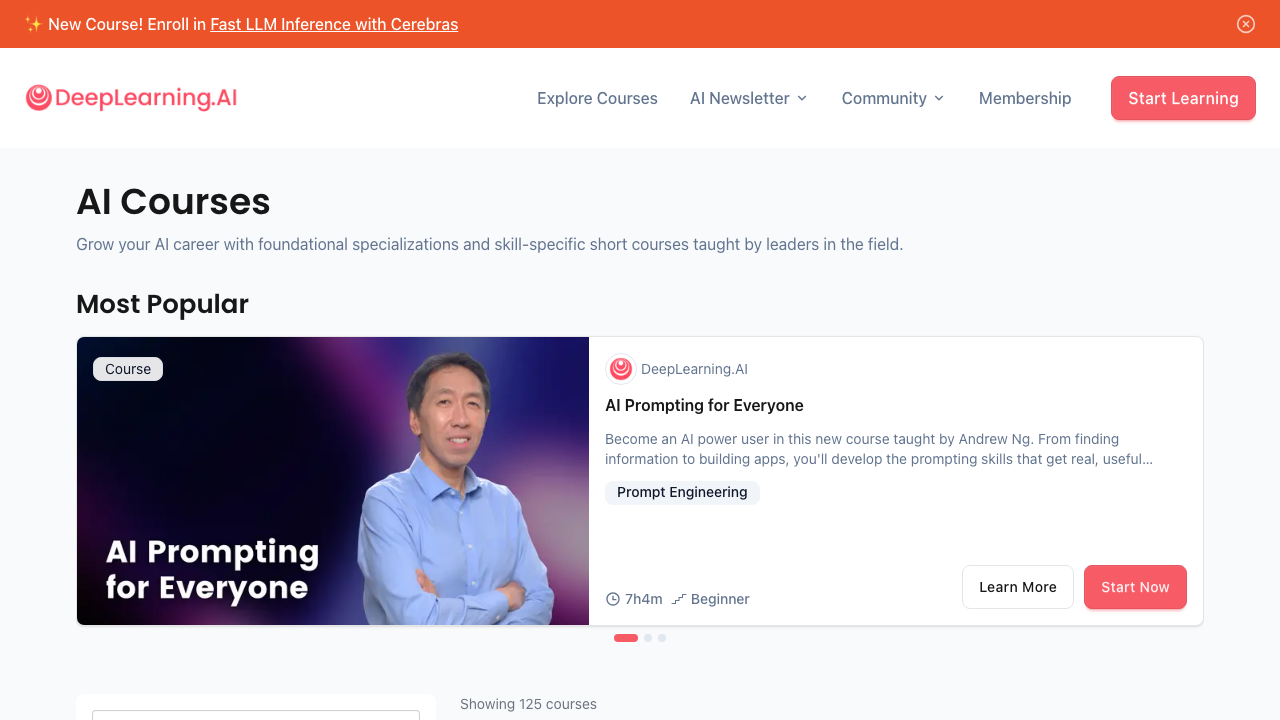

In [27]:
await visualizeCourses(result=result,
                       screenshot=screenshot,
                       target_url=target_url,
                       instructions=instructions,
                       base_url=base_url)